# TASK1:REGRESSION ANALYSIS 

In [1]:
import pandas as pd

#load the dataset
df= pd.read_csv('2) Stock Prices Data Set.csv')

#look at the first 5 rows
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
#import the tools needed to split the data
from sklearn.model_selection import train_test_split

#set our X(what we use to predict) and y(what we want to predict)
# Notice X has double bracketss because scikit-learn expects a 2D table for features
X = df[['open']]
y = df['close']

#split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#check how many rows went into each pile
print("Training data rows:", X_train.shape[0])
print("Testing data rows:", y_test.shape[0])

Training data rows: 17294
Testing data rows: 4324


In [6]:
# import the Linear Regression alogrithm
from sklearn.linear_model import LinearRegression

# create a model
model = LinearRegression()

# Train (fit) the model using only our training pile 
model.fit(X_train, y_train)

print ("model training complete!")

model training complete!


In [8]:
# import the evaluation tools
from sklearn.metrics import mean_squared_error, r2_score

# make prediction using the test data 
y_pred = model.predict(X_test)

# calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# print the results
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 2.059235874307346
R-squared: 0.9997061759488022


In [9]:
# print the coefficient ( the slope0 and intercept
print("coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

coefficient: 1.0019927831835724
Intercept: -0.0976035367761483


# TASK2: TIME SERIES ANALYSIS

In [14]:
df.dtypes

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [17]:
#convert the 'date' column to actual datetime object
df['date'] = pd.to_datetime(df['date'])

#set the 'date' column as the index ( row labels)
df.set_index('date', inplace=True)

#look at the top row to see the change
df.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


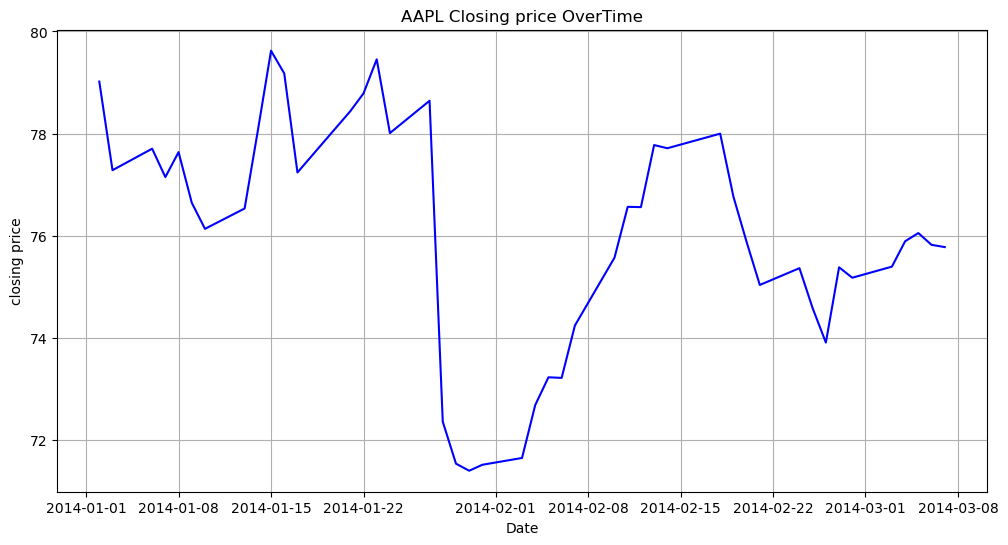

In [21]:

import matplotlib.pyplot as plt

# filter the dataset to onlt include Apple(AAPL)
aapl_data = df[df['symbol'] == 'AAPL']

#plot the closing time over time
plt.figure(figsize=(12, 6))
plt.plot(aapl_data.index, aapl_data['close'], color='blue')
plt.title('AAPL Closing price OverTime')
plt.xlabel('Date')
plt.ylabel('closing price')
plt.grid(True)
plt.show()


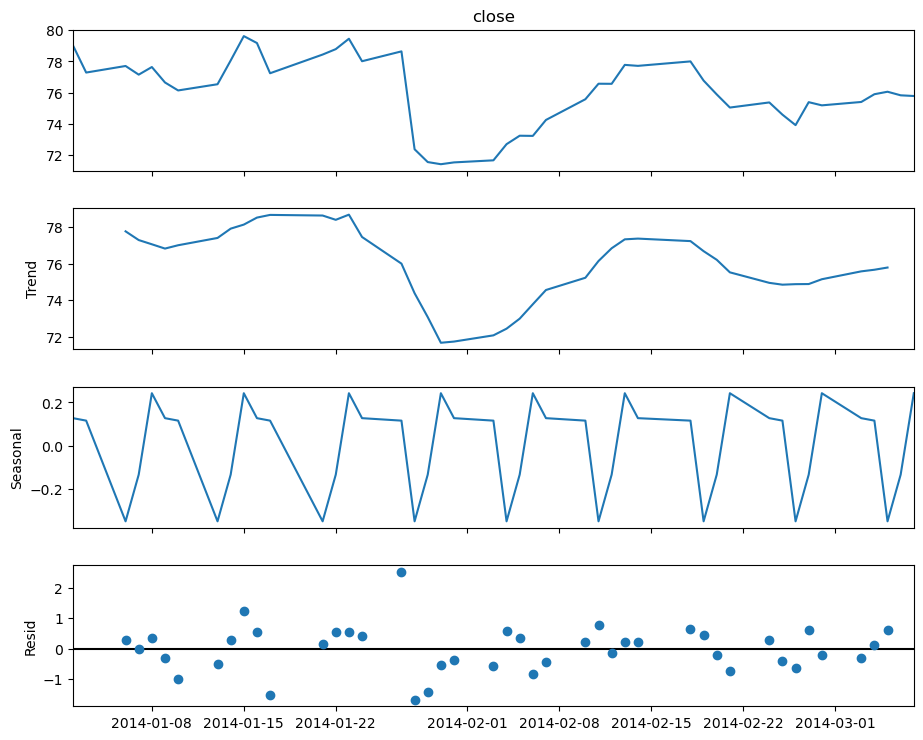

In [22]:
# import the  decomposition tool from statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the AAPl closing prices
# We use period=5 because stock market is open 5 days a week
decomposition = seasonal_decompose(aapl_data['close'], model='additive', period=5)

#plot all the separate lines
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

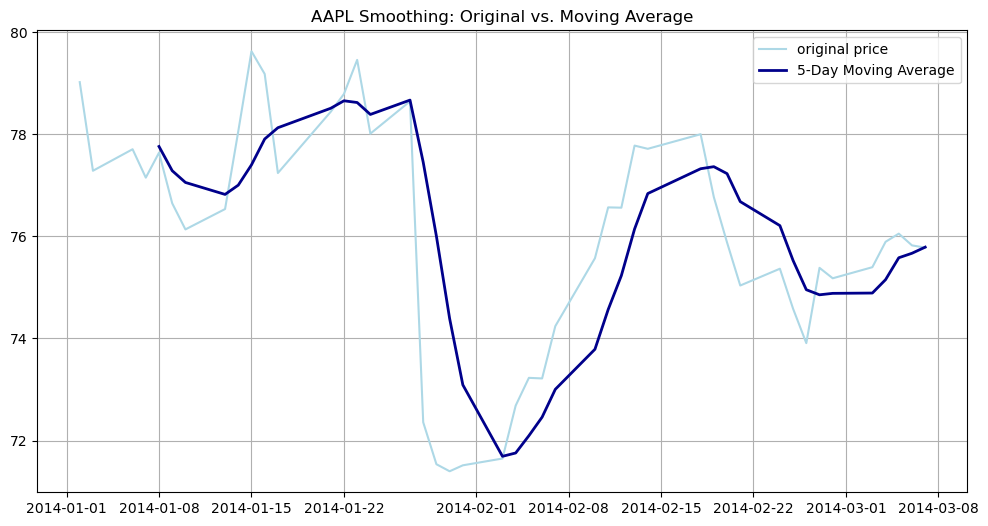

In [23]:
# calculate a 5-day moving avreage
moving_avg = aapl_data['close'].rolling(window=5).mean()

#plot the original close price and the new moving average together
plt.figure(figsize=(12, 6))
plt.plot(aapl_data.index, aapl_data['close'], label='original price', color='lightblue')
plt.plot(aapl_data.index, moving_avg, label='5-Day Moving Average', color='darkblue', linewidth=2)
plt.title('AAPL Smoothing: Original vs. Moving Average')
plt.legend()
plt.grid(True)
plt.show()